# SpaceX Falcon 9 First Stage Landing Prediction

## Exploring and Preparing Data

I am performing exploratory Data Analysis and Feature Engineering using Pandas and Matplotlib



In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot  as  plt
import seaborn as sns

<ipython-input-2-5bdd22c4a400>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


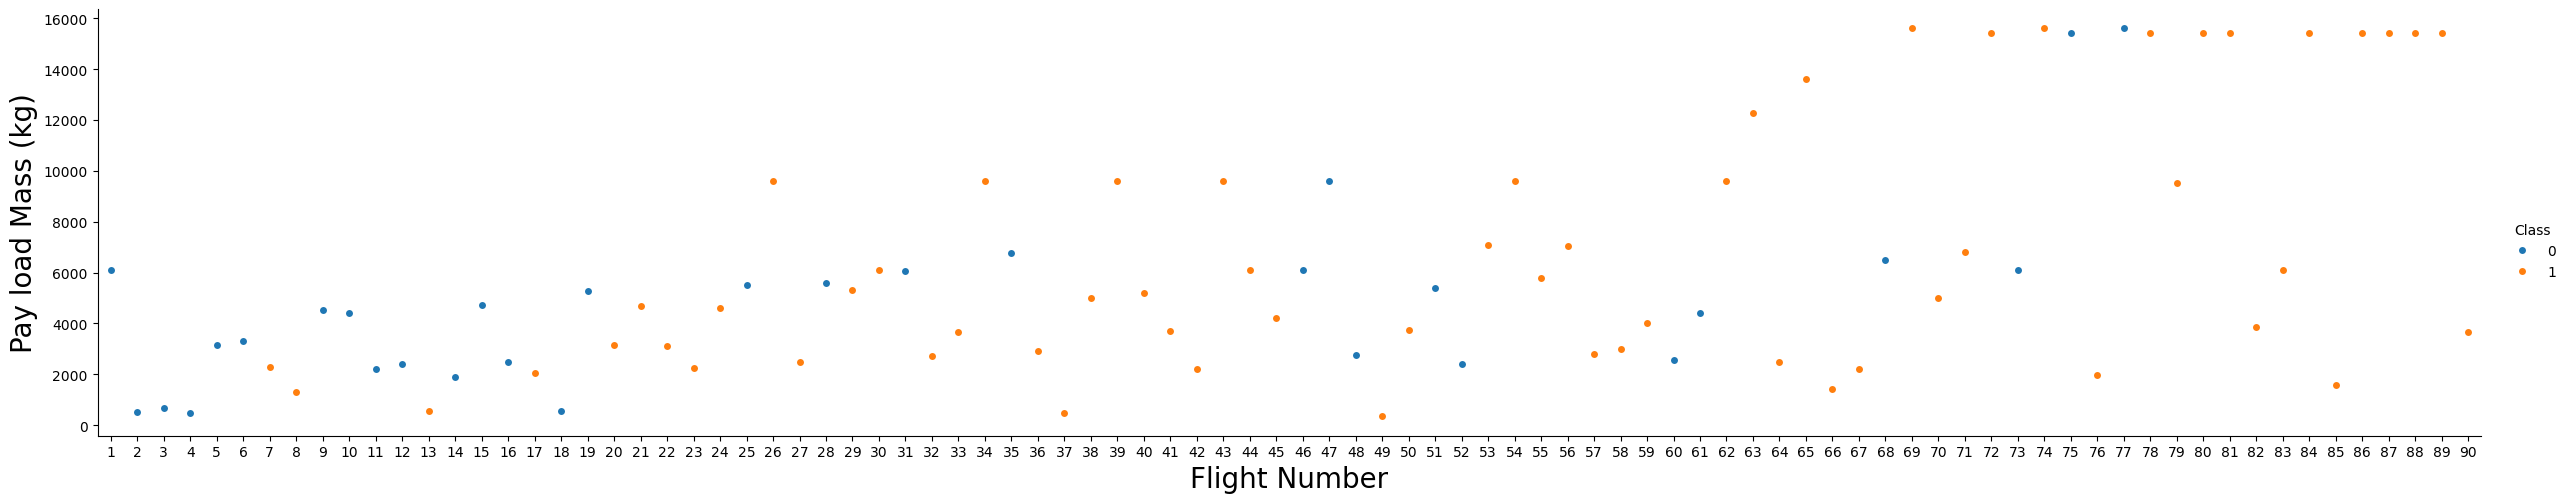

In [4]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

### The relationship between Flight Number and Launch Site

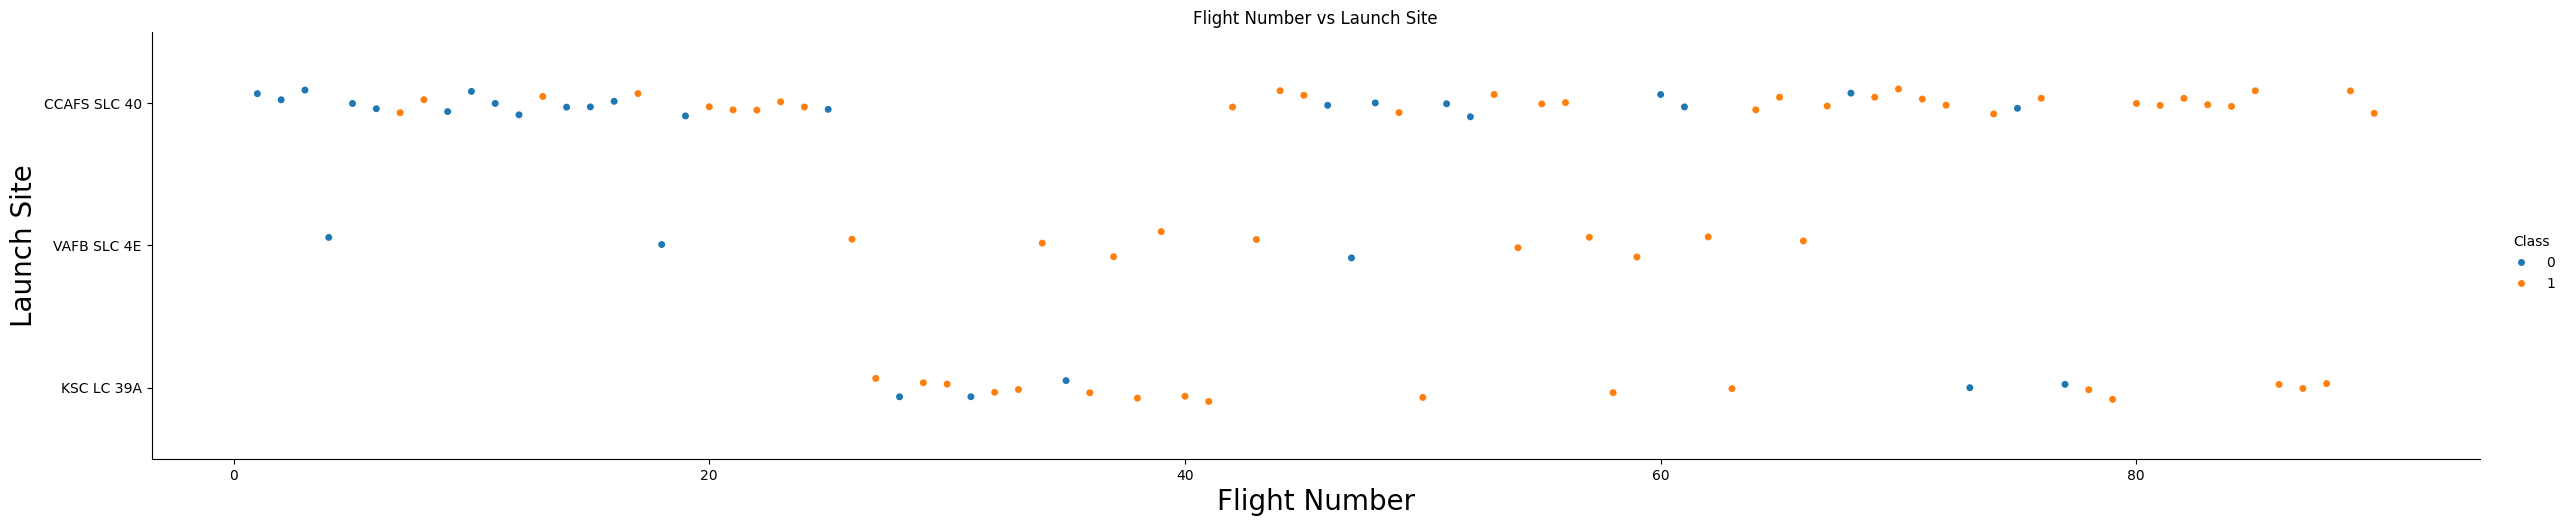

In [5]:
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df,aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.title("Flight Number vs Launch Site")
plt.show()

### The relationship between Payload Mass and Launch Site

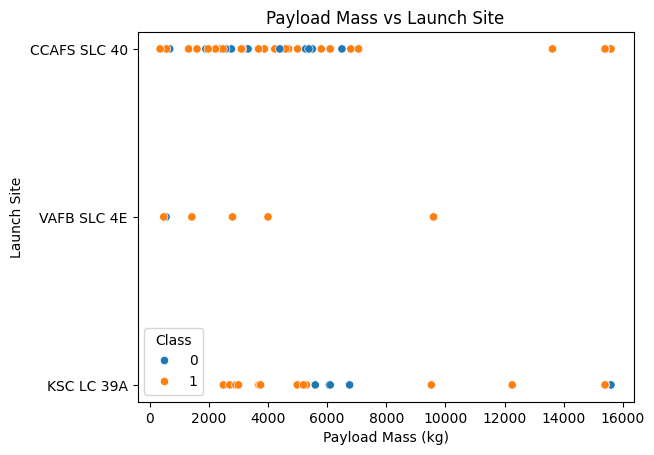

In [6]:
plt.figure()
sns.scatterplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.title("Payload Mass vs Launch Site")
plt.show()

### The relationship between success rate of each orbit type

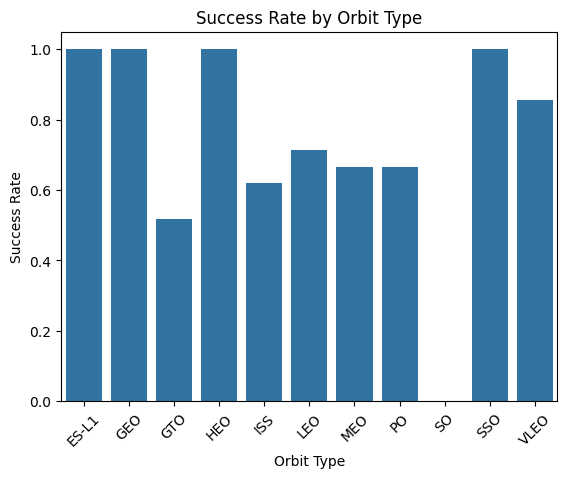

In [7]:
orbit_success = df.groupby("Orbit")["Class"].mean().reset_index()

plt.figure()
sns.barplot(x="Orbit", y="Class", data=orbit_success)
plt.xticks(rotation=45)
plt.xlabel("Orbit Type")
plt.ylabel("Success Rate")
plt.title("Success Rate by Orbit Type")
plt.show()

### The relationship between FlightNumber and Orbit type

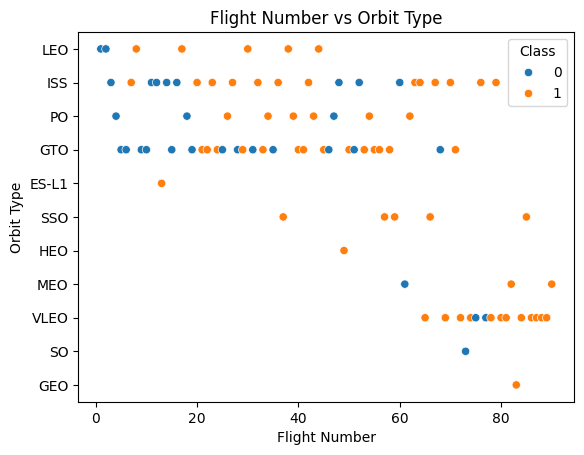

In [8]:
plt.figure()
sns.scatterplot(x="FlightNumber", y="Orbit", hue="Class", data=df)

plt.xlabel("Flight Number")
plt.ylabel("Orbit Type")
plt.title("Flight Number vs Orbit Type")

plt.show()

 ### The relationship between Payload Mass and Orbit type

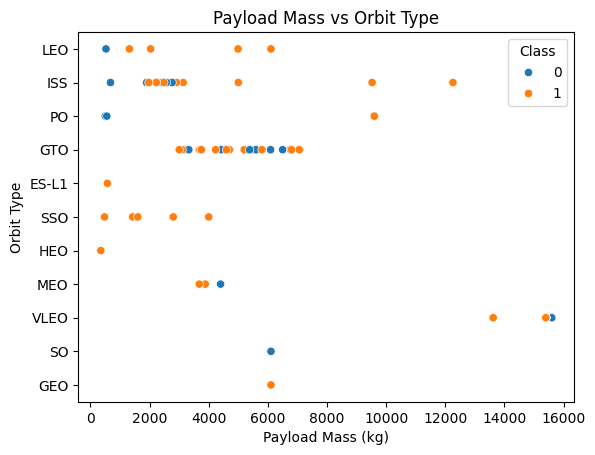

In [9]:
plt.figure()
sns.scatterplot(x="PayloadMass", y="Orbit", hue="Class", data=df)

plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit Type")
plt.title("Payload Mass vs Orbit Type")

plt.show()

### The launch success yearly trend

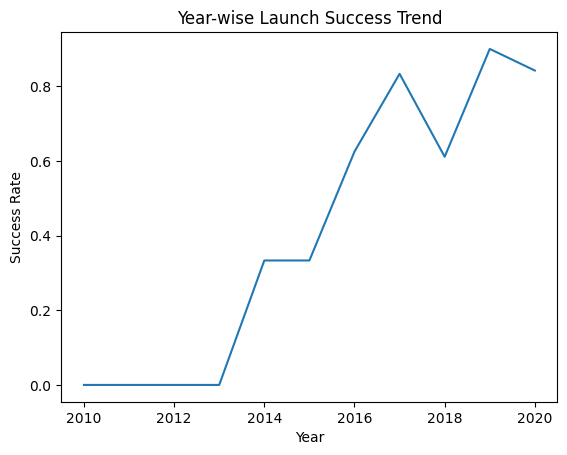

In [10]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year
df['Year'] = df['Date'].dt.year

# Calculate success rate per year
year_success = df.groupby("Year")["Class"].mean().reset_index()

# Plot
plt.figure()
sns.lineplot(x="Year", y="Class", data=year_success)

plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.title("Year-wise Launch Success Trend")

plt.show()

From the analysis, it can be observed that launch success improves with increasing flight number and over the years. 

Certain orbit types and payload ranges show higher success rates, indicating their importance in predicting landing outcomes.

## ⚙️ Feature Engineering

In this step, I converted categorical variables into numerical format using one-hot encoding. 

This is important because machine learning models cannot work directly with categorical data. 

After encoding, I converted all features into float64 type and saved the dataset for model building.

In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [12]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
features_one_hot = features_one_hot.astype('float64')

features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

In [ ]:
#features_one_hot.to_csv('dataset_part_3.csv', index=False)